# AI Prompt Duplicate Detector



In [ ]:
# =============================================================
!pip -q install datasets rapidfuzz wordcloud joblib

import re, math, random, os, json, string, warnings
warnings.filterwarnings('ignore')
from collections import Counter, defaultdict, deque

import numpy as np
import pandas as pd

from datasets import load_dataset
from rapidfuzz import fuzz

import matplotlib.pyplot as plt
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import joblib

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
MAX_ROWS = 20000       # increase to 50000 or more in Colab if runtime permits
TEST_SIZE = 0.25



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 18.9 MB/s eta 0:00:00


In [ ]:
# =============================================================
# 2. DOWNLOAD ONLINE DATASET


In [ ]:
# =============================================================
# This dataset is downloaded directly from Hugging Face.
# It is a labeled duplicate-pair dataset and works well as prompt-pair training data.

def load_online_prompt_pairs(max_rows=MAX_ROWS):
    print('Downloading online dataset from Hugging Face...')
    ds = load_dataset('sentence-transformers/quora-duplicates', 'pair-class', split='train')
    df = ds.to_pandas()[['sentence1', 'sentence2', 'label']].dropna()
    df = df.rename(columns={'sentence1':'prompt_1', 'sentence2':'prompt_2', 'label':'is_duplicate'})
    df['is_duplicate'] = df['is_duplicate'].astype(int)
    # Stratified sample for speed
    if len(df) > max_rows:
        df, _ = train_test_split(df, train_size=max_rows, stratify=df['is_duplicate'], random_state=SEED)
        df = df.reset_index(drop=True)
    return df

df = load_online_prompt_pairs()
print(df.shape)
display(df.head())
print(df['is_duplicate'].value_counts(normalize=True).rename('ratio'))



README.md: 0.00B [00:00, ?B/s]

pair-class/train-00000-of-00001.parquet:   0%|          | 0.00/35.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/404290 [00:00<?, ? examples/s]

(20000, 3)


,prompt_1,prompt_2,is_duplicate
0,How do you write a good summary of a poem?,How can we write a good summary to a given pas...,0
1,What is the skill test for SSC stenographer? W...,What is the difference between shorthand typin...,0
2,If gawker had its assets protected in a differ...,Do private wealth managers really make a diffe...,0
3,How are goblet cells in the digestive system a...,"In digestion, what are the functions of HCL?",0
4,How do you study for the reading section on th...,How should I prepare for new SAT reading section?,1


is_duplicate
0    0.6308
1    0.3692
Name: ratio, dtype: float64


In [ ]:
# =============================================================
# 3. TEXT CLEANING AND TOKENIZATION


In [ ]:
# =============================================================
STOPWORDS = set('''a an the is are am was were be been being to of and or in on for from with without by as at this that these those it its into about how what why when where who whom which do does did can could should would will shall may might i you he she they we my your our their his her them us not no yes if then than so such'''.split())

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize(text, remove_stop=True):
    tokens = clean_text(text).split()
    if remove_stop:
        tokens = [t for t in tokens if t not in STOPWORDS]
    return tokens

df['p1_clean'] = df['prompt_1'].map(clean_text)
df['p2_clean'] = df['prompt_2'].map(clean_text)
df['pair_text'] = df['p1_clean'] + ' [SEP] ' + df['p2_clean']



In [ ]:
# =============================================================
# 4. DATA STRUCTURES AND ALGORITHMS


In [ ]:
# =============================================================
class TrieNode:
    def __init__(self):
        self.children = {}
        self.count = 0
        self.is_end = False

class Trie:
    def __init__(self):
        self.root = TrieNode()
    def insert(self, phrase):
        node = self.root
        for token in tokenize(phrase, remove_stop=False):
            node = node.children.setdefault(token, TrieNode())
            node.count += 1
        node.is_end = True
    def prefix_count(self, phrase, k=3):
        node = self.root
        tokens = tokenize(phrase, remove_stop=False)[:k]
        if not tokens:
            return 0
        for token in tokens:
            if token not in node.children:
                return 0
            node = node.children[token]
        return node.count

class InvertedIndex:
    def __init__(self):
        self.index = defaultdict(set)
    def add(self, doc_id, text):
        for tok in set(tokenize(text)):
            self.index[tok].add(doc_id)
    def candidates(self, text, top_k=10):
        scores = Counter()
        for tok in set(tokenize(text)):
            for doc_id in self.index.get(tok, []):
                scores[doc_id] += 1
        return scores.most_common(top_k)

def kmp_lps(pattern):
    lps = [0] * len(pattern)
    j = 0
    for i in range(1, len(pattern)):
        while j > 0 and pattern[i] != pattern[j]:
            j = lps[j-1]
        if pattern[i] == pattern[j]:
            j += 1
            lps[i] = j
    return lps

def kmp_search(text, pattern):
    if not pattern:
        return True
    lps = kmp_lps(pattern)
    j = 0
    for ch in text:
        while j > 0 and ch != pattern[j]:
            j = lps[j-1]
        if ch == pattern[j]:
            j += 1
            if j == len(pattern):
                return True
    return False

def word_shingles(text, k=3):
    toks = tokenize(text)
    if len(toks) < k:
        return {' '.join(toks)} if toks else set()
    return {' '.join(toks[i:i+k]) for i in range(len(toks)-k+1)}

def rabin_karp_hashes(text, k=3, base=257, mod=10**9+7):
    toks = tokenize(text)
    hashes = set()
    for i in range(max(0, len(toks)-k+1)):
        h = 0
        for token in toks[i:i+k]:
            for ch in token:
                h = (h * base + ord(ch)) % mod
            h = (h * base + 32) % mod
        hashes.add(h)
    return hashes

# Simple MinHash implementation, no external MinHash library required.
HASH_PRIME = 4294967311
MINHASH_PERMS = 64
A = np.random.randint(1, HASH_PRIME-1, size=MINHASH_PERMS, dtype=np.int64)
B = np.random.randint(0, HASH_PRIME-1, size=MINHASH_PERMS, dtype=np.int64)

def stable_int_hash(s):
    h = 2166136261
    for ch in s:
        h = (h ^ ord(ch)) * 16777619
        h = h & 0xffffffff
    return h

def minhash_signature(shingles):
    if not shingles:
        return np.full(MINHASH_PERMS, HASH_PRIME, dtype=np.int64)
    vals = np.array([stable_int_hash(x) for x in shingles], dtype=np.int64)
    sig = np.full(MINHASH_PERMS, HASH_PRIME, dtype=np.int64)
    for i in range(MINHASH_PERMS):
        sig[i] = np.min((A[i] * vals + B[i]) % HASH_PRIME)
    return sig

def minhash_similarity(text1, text2):
    s1, s2 = word_shingles(text1), word_shingles(text2)
    sig1, sig2 = minhash_signature(s1), minhash_signature(s2)
    return float(np.mean(sig1 == sig2))

# Build trie and inverted index from online prompts
trie = Trie()
inv_index = InvertedIndex()
all_prompts = pd.concat([df['prompt_1'], df['prompt_2']], ignore_index=True).dropna().drop_duplicates().reset_index(drop=True)
for i, prompt in enumerate(all_prompts.head(50000)):
    trie.insert(prompt)
    inv_index.add(i, prompt)



In [ ]:
# =============================================================
# 5. FEATURE ENGINEERING


In [ ]:
# =============================================================
def jaccard(a, b):
    A, B = set(tokenize(a)), set(tokenize(b))
    return len(A & B) / max(1, len(A | B))

def dice_coef(a, b):
    A, B = set(tokenize(a)), set(tokenize(b))
    return 2 * len(A & B) / max(1, len(A) + len(B))

def overlap_ratio(a, b):
    A, B = set(tokenize(a)), set(tokenize(b))
    return len(A & B) / max(1, min(len(A), len(B)))

def shared_rk_ratio(a, b):
    A, B = rabin_karp_hashes(a), rabin_karp_hashes(b)
    return len(A & B) / max(1, len(A | B))

def common_phrase_kmp(a, b):
    toks = tokenize(a, remove_stop=False)
    if len(toks) < 3:
        return 0
    phrase = ' '.join(toks[:3])
    return int(kmp_search(clean_text(b), phrase))

def build_numeric_features(data):
    rows = []
    for q1, q2 in zip(data['prompt_1'], data['prompt_2']):
        t1, t2 = tokenize(q1), tokenize(q2)
        c1, c2 = clean_text(q1), clean_text(q2)
        rk1, rk2 = rabin_karp_hashes(q1), rabin_karp_hashes(q2)
        rows.append({
            'len_1': len(c1),
            'len_2': len(c2),
            'len_diff': abs(len(c1)-len(c2)),
            'word_count_1': len(t1),
            'word_count_2': len(t2),
            'word_count_diff': abs(len(t1)-len(t2)),
            'jaccard': jaccard(q1,q2),
            'dice': dice_coef(q1,q2),
            'overlap_ratio': overlap_ratio(q1,q2),
            'rapidfuzz_token_set': fuzz.token_set_ratio(q1,q2)/100.0,
            'rapidfuzz_partial': fuzz.partial_ratio(q1,q2)/100.0,
            'shared_rabin_karp': len(rk1 & rk2)/max(1,len(rk1 | rk2)),
            'minhash_sim': minhash_similarity(q1,q2),
            'common_start_phrase_kmp': common_phrase_kmp(q1,q2),
            'prefix_frequency_1': trie.prefix_count(q1, k=3),
            'prefix_frequency_2': trie.prefix_count(q2, k=3),
        })
    return pd.DataFrame(rows)

features = build_numeric_features(df)
display(features.head())



,len_1,len_2,len_diff,word_count_1,word_count_2,word_count_diff,jaccard,dice,overlap_ratio,rapidfuzz_token_set,rapidfuzz_partial,shared_rabin_karp,minhash_sim,common_start_phrase_kmp,prefix_frequency_1,prefix_frequency_2
0,41,50,9,4,5,1,0.500000,0.666667,0.750000,0.750000,0.784810,0.25,0.25,0,700,94
1,68,77,9,6,8,2,0.200000,0.333333,0.333333,0.616541,0.632479,0.00,0.00,1,3278,3278
2,110,218,108,11,24,13,0.060606,0.114286,0.181818,0.463855,0.464286,0.00,0.00,0,1,1
3,76,42,34,7,3,4,0.000000,0.000000,0.000000,0.528926,0.493506,0.00,0.00,0,1,1
4,55,48,7,5,5,0,0.666667,0.800000,0.800000,0.732673,0.651685,0.00,0.00,0,700,130


In [ ]:
# =============================================================
# 6. VISUAL EXPLORATION


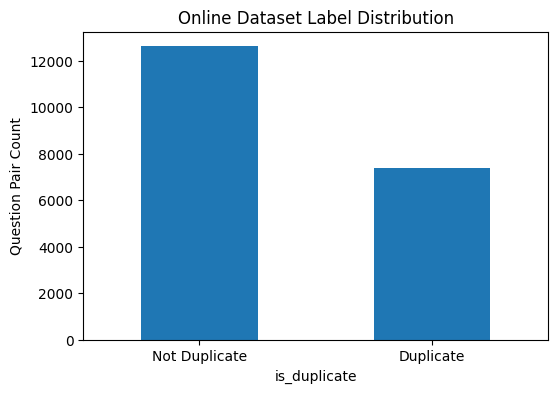

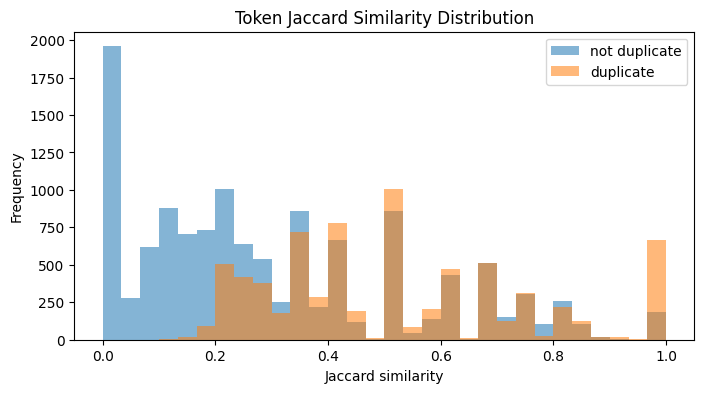

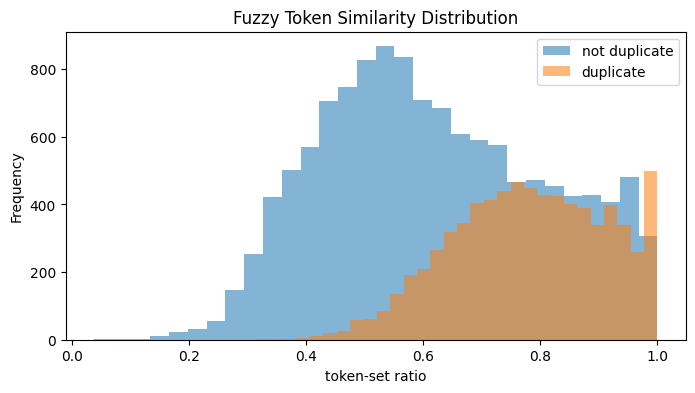

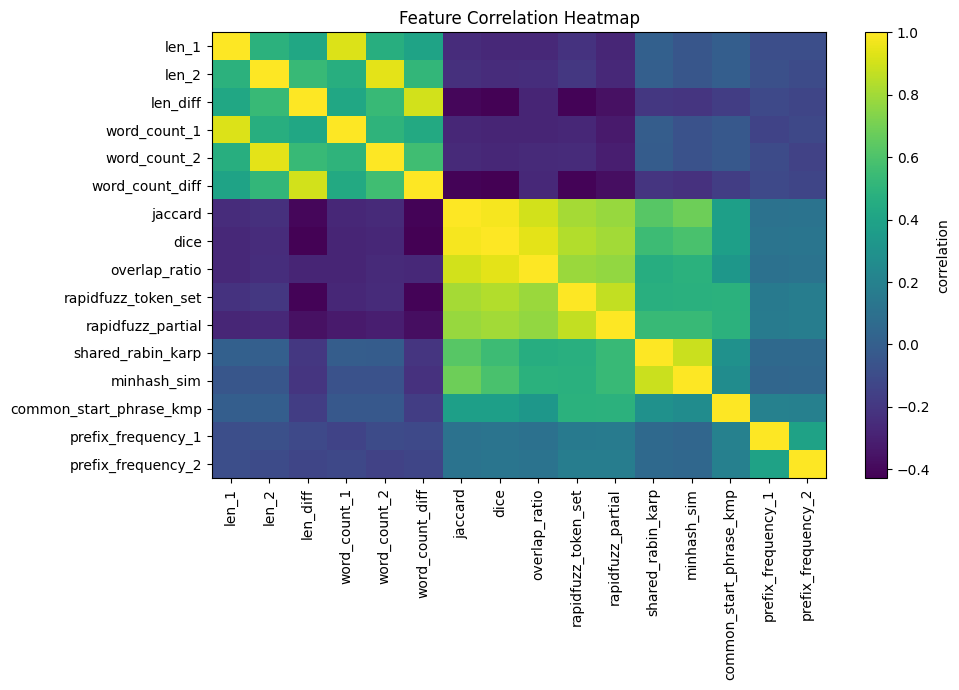

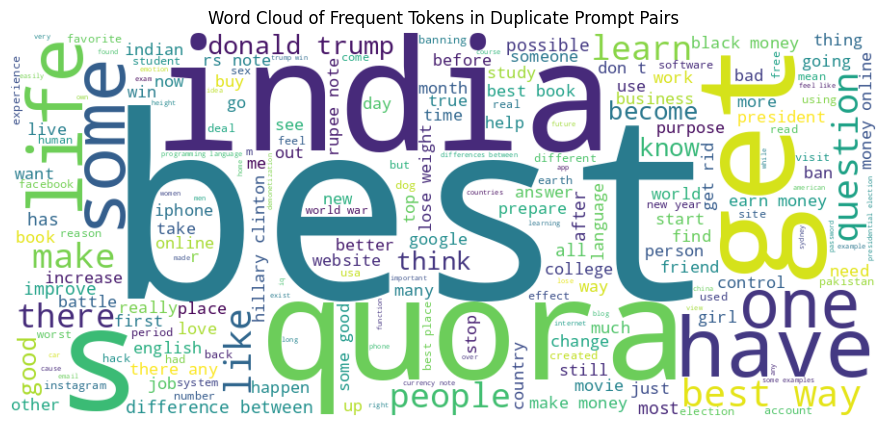

In [ ]:
# =============================================================
plt.figure(figsize=(6,4))
df['is_duplicate'].value_counts().sort_index().plot(kind='bar')
plt.xticks([0,1], ['Not Duplicate', 'Duplicate'], rotation=0)
plt.title('Online Dataset Label Distribution')
plt.ylabel('Question Pair Count')
plt.show()

plt.figure(figsize=(8,4))
plt.hist(features.loc[df.is_duplicate==0, 'jaccard'], bins=30, alpha=0.55, label='not duplicate')
plt.hist(features.loc[df.is_duplicate==1, 'jaccard'], bins=30, alpha=0.55, label='duplicate')
plt.title('Token Jaccard Similarity Distribution')
plt.xlabel('Jaccard similarity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

plt.figure(figsize=(8,4))
plt.hist(features.loc[df.is_duplicate==0, 'rapidfuzz_token_set'], bins=30, alpha=0.55, label='not duplicate')
plt.hist(features.loc[df.is_duplicate==1, 'rapidfuzz_token_set'], bins=30, alpha=0.55, label='duplicate')
plt.title('Fuzzy Token Similarity Distribution')
plt.xlabel('token-set ratio')
plt.ylabel('Frequency')
plt.legend()
plt.show()

corr = features.corr(numeric_only=True)
plt.figure(figsize=(10,7))
plt.imshow(corr, aspect='auto')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar(label='correlation')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# Frequent tokens in duplicate pairs
text_dup = ' '.join(df.loc[df.is_duplicate==1, 'p1_clean'].head(5000).tolist() + df.loc[df.is_duplicate==1, 'p2_clean'].head(5000).tolist())
wc = WordCloud(width=900, height=400, background_color='white', stopwords=STOPWORDS).generate(text_dup)
plt.figure(figsize=(12,5))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Frequent Tokens in Duplicate Prompt Pairs')
plt.show()



In [ ]:
# =============================================================
# 7. TRAIN / TEST SPLIT


In [ ]:
# =============================================================
y = df['is_duplicate'].values
X_train_df, X_test_df, y_train, y_test, f_train, f_test = train_test_split(
    df, y, features, test_size=TEST_SIZE, stratify=y, random_state=SEED
)



In [ ]:
# =============================================================
# 8. MODEL 1: RULE-BASED BASELINE


In [ ]:
# =============================================================
def rule_based_score(row):
    score = 0
    score += 0.30 if row['jaccard'] >= 0.45 else 0
    score += 0.25 if row['rapidfuzz_token_set'] >= 0.70 else 0
    score += 0.20 if row['minhash_sim'] >= 0.35 else 0
    score += 0.15 if row['shared_rabin_karp'] >= 0.25 else 0
    score += 0.10 if row['word_count_diff'] <= 3 else 0
    return min(score, 1.0)

rule_scores = f_test.apply(rule_based_score, axis=1).values
rule_pred = (rule_scores >= 0.55).astype(int)
print('Rule-Based Baseline')
print(classification_report(y_test, rule_pred, digits=4))



Rule-Based Baseline
              precision    recall  f1-score   support

           0     0.7130    0.7768    0.7436      3154
           1     0.5499    0.4659    0.5044      1846

    accuracy                         0.6620      5000
   macro avg     0.6315    0.6213    0.6240      5000
weighted avg     0.6528    0.6620    0.6553      5000



In [ ]:
# =============================================================
# 9. MODEL 2: NUMERIC FEATURES RANDOM FOREST


Random Forest Numeric Feature Model
              precision    recall  f1-score   support

           0     0.7983    0.7815    0.7898      3154
           1     0.6396    0.6625    0.6509      1846

    accuracy                         0.7376      5000
   macro avg     0.7189    0.7220    0.7203      5000
weighted avg     0.7397    0.7376    0.7385      5000

ROC-AUC: 0.8238227472242852


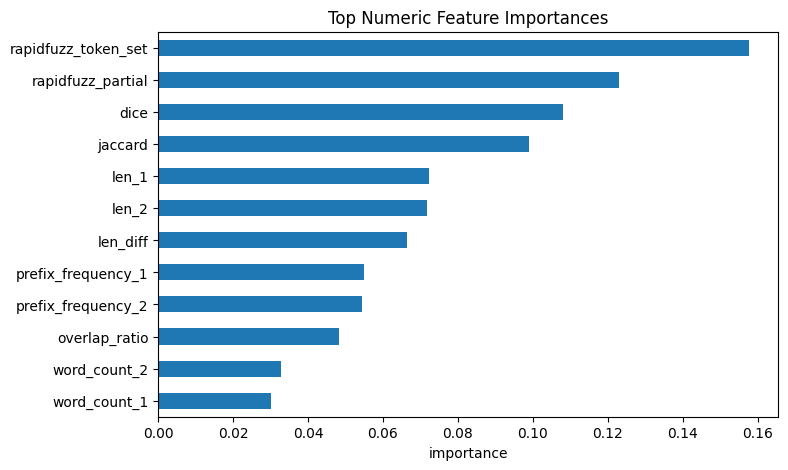

In [ ]:
# =============================================================
rf = RandomForestClassifier(n_estimators=250, random_state=SEED, class_weight='balanced', n_jobs=-1)
rf.fit(f_train, y_train)
rf_prob = rf.predict_proba(f_test)[:,1]
rf_pred = (rf_prob >= 0.5).astype(int)
print('Random Forest Numeric Feature Model')
print(classification_report(y_test, rf_pred, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, rf_prob))

imp = pd.Series(rf.feature_importances_, index=f_train.columns).sort_values(ascending=False).head(12)
plt.figure(figsize=(8,5))
imp.sort_values().plot(kind='barh')
plt.title('Top Numeric Feature Importances')
plt.xlabel('importance')
plt.show()



In [ ]:
# =============================================================
# 10. MODEL 3: TF-IDF + NUMERIC FEATURES LOGISTIC REGRESSION


Hybrid Model: Char TF-IDF + DSA Numeric Features
              precision    recall  f1-score   support

           0     0.8707    0.7216    0.7892      3154
           1     0.6320    0.8169    0.7127      1846

    accuracy                         0.7568      5000
   macro avg     0.7514    0.7693    0.7509      5000
weighted avg     0.7826    0.7568    0.7609      5000

ROC-AUC: 0.8493701097370036


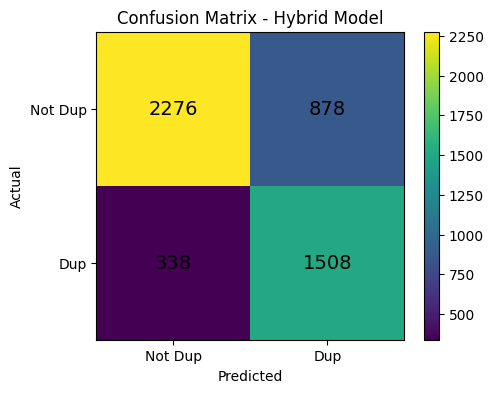

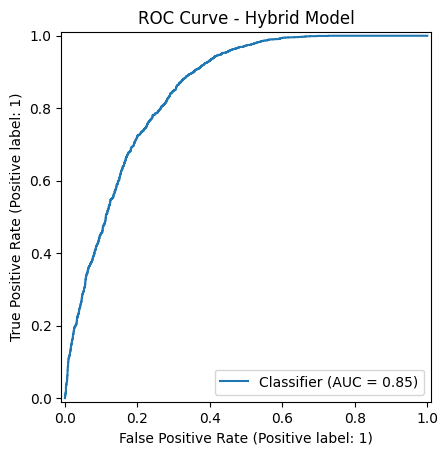

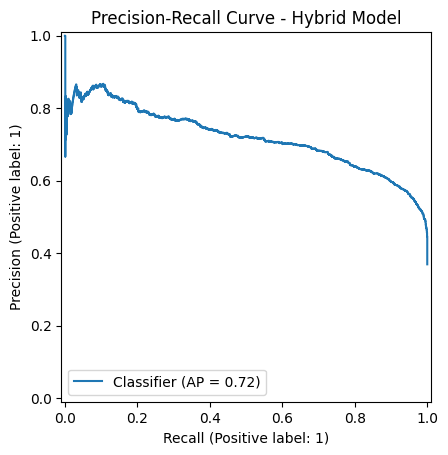

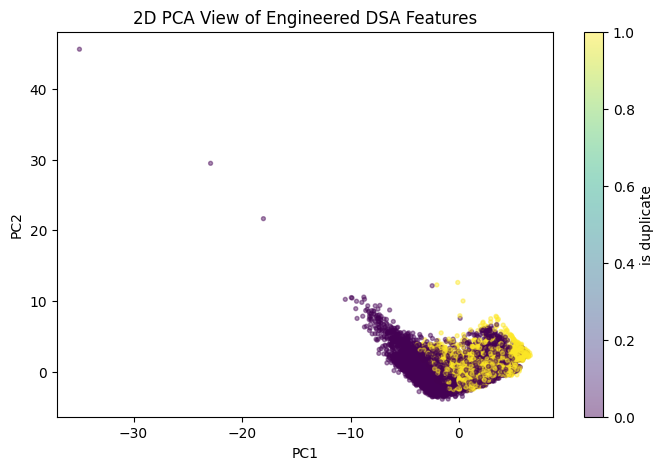

In [ ]:
# =============================================================
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2, max_features=80000)
X_train_text = vectorizer.fit_transform(X_train_df['pair_text'])
X_test_text = vectorizer.transform(X_test_df['pair_text'])
scaler = StandardScaler()
X_train_num = scaler.fit_transform(f_train)
X_test_num = scaler.transform(f_test)
X_train_all = hstack([X_train_text, csr_matrix(X_train_num)])
X_test_all = hstack([X_test_text, csr_matrix(X_test_num)])

clf = LogisticRegression(max_iter=1000, class_weight='balanced', n_jobs=-1)
clf.fit(X_train_all, y_train)
prob = clf.predict_proba(X_test_all)[:,1]
pred = (prob >= 0.5).astype(int)
print('Hybrid Model: Char TF-IDF + DSA Numeric Features')
print(classification_report(y_test, pred, digits=4))
print('ROC-AUC:', roc_auc_score(y_test, prob))

cm = confusion_matrix(y_test, pred)
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title('Confusion Matrix - Hybrid Model')
plt.xticks([0,1], ['Not Dup','Dup'])
plt.yticks([0,1], ['Not Dup','Dup'])
for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i,j],ha='center',va='center',fontsize=14)
plt.colorbar()
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

RocCurveDisplay.from_predictions(y_test, prob)
plt.title('ROC Curve - Hybrid Model')
plt.show()

PrecisionRecallDisplay.from_predictions(y_test, prob)
plt.title('Precision-Recall Curve - Hybrid Model')
plt.show()

# PCA visualization of numeric features
scaled_all = StandardScaler().fit_transform(features)
pca = PCA(n_components=2, random_state=SEED)
pts = pca.fit_transform(scaled_all)
plt.figure(figsize=(8,5))
plt.scatter(pts[:,0], pts[:,1], c=df['is_duplicate'], s=8, alpha=0.45)
plt.title('2D PCA View of Engineered DSA Features')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='is duplicate')
plt.show()



In [ ]:
# =============================================================
# 11. CUSTOM AI PROMPT TESTING + CHANGE VISUALIZATION



PROMPT 1: Explain machine learning in simple terms
PROMPT 2: Can you explain machine learning simply?
{'duplicate_probability': 0.6465, 'label': 'DUPLICATE / SAME INTENT', 'shared_tokens': ['explain', 'learning', 'machine'], 'tokens_only_in_prompt_1': ['simple', 'terms'], 'tokens_only_in_prompt_2': ['simply'], 'jaccard': 0.5, 'minhash_sim': 0.2031, 'rabin_karp_shared': 0.25, 'fuzzy_token_set': 0.75, 'prefix_frequency_1': 0, 'prefix_frequency_2': 5}

PROMPT 1: Write Python code for merge sort
PROMPT 2: Create a recipe for chocolate cake
{'duplicate_probability': 0.0204, 'label': 'NOT DUPLICATE / DIFFERENT INTENT', 'shared_tokens': [], 'tokens_only_in_prompt_1': ['code', 'merge', 'python', 'sort', 'write'], 'tokens_only_in_prompt_2': ['cake', 'chocolate', 'create', 'recipe'], 'jaccard': 0.0, 'minhash_sim': 0.0, 'rabin_karp_shared': 0.0, 'fuzzy_token_set': 0.4242, 'prefix_frequency_1': 0, 'prefix_frequency_2': 0}

PROMPT 1: Summarize this paragraph into bullet points
PROMPT 2: Make bulle

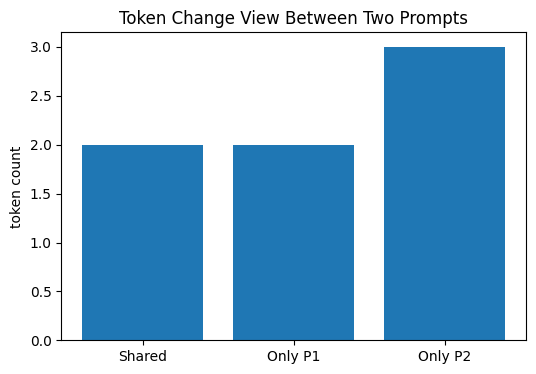

{
  "duplicate_probability": 0.3216,
  "label": "NOT DUPLICATE / DIFFERENT INTENT",
  "shared_tokens": [
    "blockchain",
    "explain"
  ],
  "tokens_only_in_prompt_1": [
    "five",
    "like"
  ],
  "tokens_only_in_prompt_2": [
    "beginner",
    "simple",
    "words"
  ],
  "jaccard": 0.2857,
  "minhash_sim": 0.0,
  "rabin_karp_shared": 0.0,
  "fuzzy_token_set": 0.5055,
  "prefix_frequency_1": 0,
  "prefix_frequency_2": 5
}
Candidate prompts from inverted index:
2 => I want to build a website similar to Yelp, but I don't want to write the code from scratch. What are the best frameworks to use?
2 => I write code very very slowly, how can I become a faster developer?
2 => Can you code an Android app completely in python?
2 => Software Performance: Can good code in Python be as fast as good code in Java or C++?
2 => What is the difference between scripts and programs? For example, what is the difference between Python scripting and Python code programs?


In [ ]:
# =============================================================
def explain_pair(q1, q2):
    row = build_numeric_features(pd.DataFrame({'prompt_1':[q1], 'prompt_2':[q2]})).iloc[0]
    pair_text = clean_text(q1) + ' [SEP] ' + clean_text(q2)
    xt = vectorizer.transform([pair_text])
    xn = scaler.transform(pd.DataFrame([row], columns=f_train.columns))
    xall = hstack([xt, csr_matrix(xn)])
    p = clf.predict_proba(xall)[0,1]
    t1, t2 = set(tokenize(q1)), set(tokenize(q2))
    kept = sorted(t1 & t2)
    removed = sorted(t1 - t2)
    added = sorted(t2 - t1)
    explanation = {
        'duplicate_probability': round(float(p), 4),
        'label': 'DUPLICATE / SAME INTENT' if p >= 0.5 else 'NOT DUPLICATE / DIFFERENT INTENT',
        'shared_tokens': kept[:20],
        'tokens_only_in_prompt_1': removed[:20],
        'tokens_only_in_prompt_2': added[:20],
        'jaccard': round(float(row['jaccard']),4),
        'minhash_sim': round(float(row['minhash_sim']),4),
        'rabin_karp_shared': round(float(row['shared_rabin_karp']),4),
        'fuzzy_token_set': round(float(row['rapidfuzz_token_set']),4),
        'prefix_frequency_1': int(row['prefix_frequency_1']),
        'prefix_frequency_2': int(row['prefix_frequency_2'])
    }
    return explanation

def visualize_pair_changes(q1, q2):
    exp = explain_pair(q1, q2)
    counts = [len(exp['shared_tokens']), len(exp['tokens_only_in_prompt_1']), len(exp['tokens_only_in_prompt_2'])]
    labels = ['Shared', 'Only P1', 'Only P2']
    plt.figure(figsize=(6,4))
    plt.bar(labels, counts)
    plt.title('Token Change View Between Two Prompts')
    plt.ylabel('token count')
    plt.show()
    print(json.dumps(exp, indent=2))

custom_tests = [
    ('Explain machine learning in simple terms', 'Can you explain machine learning simply?'),
    ('Write Python code for merge sort', 'Create a recipe for chocolate cake'),
    ('Summarize this paragraph into bullet points', 'Make bullet point summary of the given paragraph'),
    ('Generate SQL query to find duplicate customers', 'How do I remove duplicates from a pandas dataframe?')
]

for a,b in custom_tests:
    print('\nPROMPT 1:', a)
    print('PROMPT 2:', b)
    print(explain_pair(a,b))

visualize_pair_changes('Explain blockchain like I am five', 'Can you explain blockchain in simple words for a beginner?')

# Candidate retrieval demo using inverted index
query_prompt = 'write python code for sorting a list'
print('Candidate prompts from inverted index:')
for doc_id, score in inv_index.candidates(query_prompt, top_k=5):
    print(score, '=>', all_prompts.iloc[doc_id])



In [ ]:
# =============================================================
# 12. EXPORT TEST RESULTS AND MODEL


In [ ]:
# =============================================================
results = X_test_df[['prompt_1','prompt_2','is_duplicate']].copy()
results['predicted_probability'] = prob
results['predicted_label'] = pred
for col in ['jaccard','minhash_sim','shared_rabin_karp','rapidfuzz_token_set','word_count_diff']:
    results[col] = f_test[col].values

results.to_csv('ai_prompt_duplicate_detector_test_results.csv', index=False)
joblib.dump({'vectorizer':vectorizer, 'scaler':scaler, 'model':clf, 'feature_columns':list(f_train.columns)}, 'ai_prompt_duplicate_detector_model.joblib')
print('Saved: ai_prompt_duplicate_detector_test_results.csv')
print('Saved: ai_prompt_duplicate_detector_model.joblib')


Saved: ai_prompt_duplicate_detector_test_results.csv
Saved: ai_prompt_duplicate_detector_model.joblib
